In [1]:
import os
from pathlib import Path


from aereo.backends import LocalProcessBackend
from aereo.client import AereoClient
from aereo.pipeline import ExtractionJob


DRY_RUN = os.environ.get("DRY_RUN", "false").lower() in ("1", "true", "yes")
job = ExtractionJob.load_from_config(
    config_dir=(Path(".").parent / "config").resolve(),
    config_name="job_viirs.yaml",
)

In [2]:
job

ExtractionJob(name='viirs_sample', derivative=None, grid_config=GridConfig(target_grid_dist=10000, target_grid_overlap=False, grid_filter_mode='intersection', min_coverage=0.0), patch_config=PatchConfig(resolution=375.0, padding=0, margin=10.0, conform_to=None), output_uri='/tmp/aereo_extraction', search=SearchEarthaccess(collections={'VJ202IMG': ['I04'], 'VJ203IMG': []}, intersects=<POLYGON ((-69.033 -38.36, -68.409 -38.36, -68.409 -38.757, -69.033 -38.757,...>, start_datetime=datetime.datetime(2024, 1, 1, 0, 0, tzinfo=TzInfo(0)), end_datetime=datetime.datetime(2024, 1, 1, 23, 59, 59, tzinfo=TzInfo(0)), search_params={}), extract=ExtractConfig(read=ReadSatpy(read_kwargs={}, reader='viirs_l1b', reader_kwargs=None, wishlist=None, calibration='*', resolution='*', polarization='*', level='*', modifiers='*', generate=True, unload=True, downloader=None, download_workers=1, output_datasets=None), preprocess=[], reproject=ReprojectSatpy(reproject_kwargs={}, reproject_params={}, supported_coll

In [4]:
def run_pipeline(job: ExtractionJob) -> None:
    """Run search → prepare → extract for a validated job.

    Args:
        job: The validated ``ExtractionJob`` to execute.
    """
    client = AereoClient()

    # Search
    print("\n🔍 Searching...")
    search_results = client.search(job.search)
    print(f"✓ Found {len(search_results)} scenes")

    if search_results.empty:
        print("No results; skipping prepare/extract.")
        return

    # Prepare
    print("\n📦 Preparing tasks...")
    tasks = client.prepare_tasks(
        search_results=search_results,
        job=job,
        cells_per_task=20,
    )
    print(f"✓ Prepared {len(tasks)} tasks")

    # Extract
    print("\n⛏️ Extracting...")
    backend = LocalProcessBackend(max_workers=2)
    artifacts = client.execute_tasks(tasks, backend=backend)
    print(f"✓ Extracted {len(artifacts)} artifacts")
    return artifacts

In [5]:
artifacts = run_pipeline(job)


🔍 Searching...
2026-06-13 16:43:24 [info     ] search_called                  provider=SearchEarthaccess


/root/repos/aereo/.venv/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/root/repos/aereo/components/aereo/builtins/search.py:320: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  size_mb = g.size()


✓ Found 4 scenes

📦 Preparing tasks...
✓ Prepared 4 tasks

⛏️ Extracting...
2026-06-13 16:43:26 [info     ] execute_tasks_start            backend=LocalProcessBackend failure_mode=strict task_count=4
2026-06-13 16:43:26 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/VJ202IMG.A2024001.0548.021.2024311130743.nc
2026-06-13 16:43:26 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/VJ203IMG.A2024001.0548.021.2024311123548.nc
2026-06-13 16:43:26 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/VJ202IMG.A2024001.0548.021.2024311130743.nc
2026-06-13 16:43:26 [debug    ] file_downloaded                engine=satpy local_path=/tmp/aereo_extraction/VJ203IMG.A2024001.0548.021.2024311123548.nc
2026-06-13 16:43:26 [error    ] local_task_failed              error="'NoneType' object is not iterable" task_index=0
2026-06-13 16:43:39 [debug    ] file_downloaded                engine=

_RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/lib/python3.13/concurrent/futures/process.py", line 254, in _process_worker
    r = call_item.fn(*call_item.args, **call_item.kwargs)
  File "/root/repos/aereo/components/aereo/backends/core.py", line 87, in run
    ds = reader(task)
  File "/root/repos/aereo/.venv/lib/python3.13/site-packages/aereo/read_satpy/core.py", line 101, in __call__
    scn.load(
    ~~~~~~~~^
        self.wishlist,
        ^^^^^^^^^^^^^^
    ...<5 lines>...
        generate=self.generate,
        ^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/root/repos/aereo/.venv/lib/python3.13/site-packages/satpy/scene.py", line 1471, in load
    dataset_keys = set(wishlist)
TypeError: 'NoneType' object is not iterable
"""

The above exception was the direct cause of the following exception:

╭─────────────────────────────────────── Traceback (most recent call last) ───────────────────────────────────────╮
│ /root/repos/aereo/bases/aereo/client/core.py:269 in execute_tasks                                               │
│                                                                                                                 │
│   266 │   │                                                                                                     │
│   267 │   │   # STRICT mode — batch for efficiency, raise on first failure                                      │
│   268 │   │   try:                                                                                              │
│ ❱ 269 │   │   │   results = list(backend.run_tasks(tasks, runner))                                              │
│   270 │   │   except Exception:                                                                                 │
│   271 │   │   │   logger.error("execute_tasks_failed", exc_info=True)                                           │
│   272 │   │   │   raise                                                                                         │
│                                                                                                                 │
│ ╭────────────────────────────────────────────────── locals ───────────────────────────────────────────────────╮ │
│ │      backend = <aereo.backends.local.LocalProcessBackend object at 0xffff2feb1fd0>                          │ │
│ │ failure_mode = <FailureMode.STRICT: 'strict'>                                                               │ │
│ │       runner = <aereo.backends.core.TaskRunner object at 0xffff2d1034d0>                                    │ │
│ │         self = <aereo.client.core.AereoClient object at 0xffff2d102510>                                     │ │
│ │        tasks = [                                                                                            │ │
│ │                │   ExtractionTask(                                                                          │ │
│ │                │   │   assets=                                 id collection  \                             │ │
│ │                0  25bc76a696486773feba8134d294baaf   VJ202IMG                                               │ │
│ │                1  3ec6bc692c26896f4d27154189b18377   VJ203IMG                                               │ │
│ │                │   │   │   │   │   │   │   │   │   │   │                                                    │ │
│ │                │   │   │   │   │   │   │   │   │   │   │   geometry          start_time  \                  │ │
│ │                0  POLYGON ((-55.43705 -31.84754, -86.46778 -27.0... 2024-01-01 05:48:00                     │ │
│ │                1  POLYGON ((-55.43705 -31.84754, -86.46778 -27.0... 2024-01-01 05:48:00                     │ │
│ │                │   │   │                                                                                    │ │
│ │                │   │   │    end_time                                               href  \                  │ │
│ │                0 2024-01-01 0

2026-06-13 16:43:39 [error    ] execute_tasks_failed          



TypeError: 'NoneType' object is not iterable

In [5]:
artifacts.iloc[120].uri

'/tmp/aereo_extraction/derivatives/ndvi/job-sentinel2_sample/loc-428D601L/date-20240110/loc-428D601L_start-20240110T142711_end-20240110T142711_job-sentinel2_sample_collection-sentinel-2-l2a_variable-ndvi_res-10m.tif'

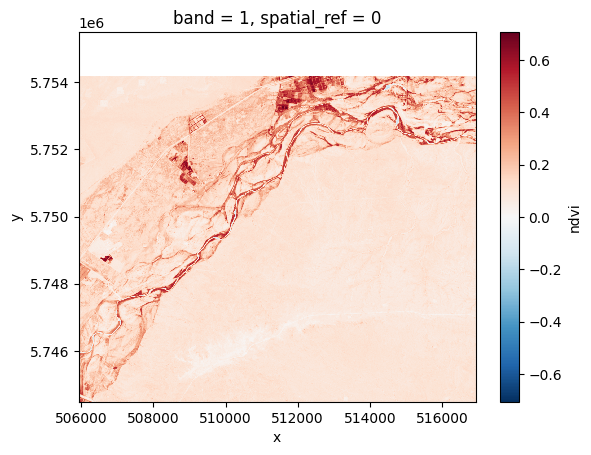

In [6]:
import rioxarray

rioxarray.open_rasterio(artifacts.iloc[120].uri).plot()